# 🌴 Nakhlah AI – Robust Real-World Training Pipeline
### Project: Nakhlah – Date Fruit Classification
### Strategy: 3-Dataset Merge + Albumentations Augmentation + Two-Stage Fine-Tuning + TTA

---

| What | Details |
|------|---------|
| **Datasets** | 3 Kaggle sources merged with prefix separation |
| **Model** | EfficientNet-B2 (260 px, ~9M params) |
| **Augmentation** | Albumentations: geometry, lighting, colour, camera artefacts, occlusion |
| **Training** | Two-stage fine-tuning (frozen → full) + MixUp + early stopping |
| **Inference** | Test-Time Augmentation (TTA, 5 views) |
| **Goal** | High accuracy on real-world photos, not just lab images |


## ⚙️ Cell 1 — Install Dependencies

In [1]:
import shutil

shutil.rmtree('/kaggle/working', ignore_errors=True)
print("✅ cleaned /kaggle/working")

✅ cleaned /kaggle/working


In [2]:
import os

os.makedirs('/kaggle/working', exist_ok=True)
print("✅ recreated working folder")

✅ recreated working folder


In [3]:
import subprocess, sys

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "kagglehub", "albumentations", "tqdm", "scikit-learn",
], check=True)
print("✅ Dependencies installed")


✅ Dependencies installed


## 📦 Cell 2 — Imports & Reproducibility

In [4]:
import os, json, time, random, copy, shutil
from pathlib import Path
from collections import Counter
from typing import Optional
from glob import glob

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image as PILImage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import models
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.auto import tqdm
import kagglehub

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥  Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


🖥  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 🗂️ Cell 3 — Config
> **Only cell you need to edit.** All paths and hyperparameters live here.


In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              ✏️  KAGGLE CONFIG                              ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Kaggle kagglehub cache → /kaggle/working ──────────────────────────────
os.environ["KAGGLEHUB_CACHE"] = "/kaggle/working/kagglehub_cache"

# ── Directory tree (all under /kaggle/working/) ───────────────────────────
BASE_DIR      = Path("/kaggle/working")
DATASET_DIR   = BASE_DIR / "dataset"
RAW_DIR       = DATASET_DIR / "raw"              # merged raw images
PROCESSED_DIR = DATASET_DIR / "processed"        # train / val / test splits
MODELS_DIR    = BASE_DIR / "models"
LOGS_DIR      = BASE_DIR / "logs"

TRAIN_DIR = PROCESSED_DIR / "train"
VAL_DIR   = PROCESSED_DIR / "val"
TEST_DIR  = PROCESSED_DIR / "test"

for d in [RAW_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR, MODELS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"✅ Directories created under {BASE_DIR}")

# ── Model & image ─────────────────────────────────────────────────────────
IMG_SIZE    = 260    # EfficientNet-B2 native size. Use 224 if OOM.
BATCH_SIZE  = 32     # Reduce to 16 if you get CUDA OOM
NUM_WORKERS = min(4, os.cpu_count() or 1)
MODEL_NAME  = "nakhlah_robust_v1"

# ── Training stages ───────────────────────────────────────────────────────
STAGE1_EPOCHS = 5      # backbone frozen, head only
STAGE1_LR     = 1e-3

STAGE2_EPOCHS = 10     # full model, fine-tune end-to-end
STAGE2_LR     = 5e-4

# ── Regularisation ────────────────────────────────────────────────────────
WEIGHT_DECAY        = 1e-4
LABEL_SMOOTHING     = 0.1
MIXUP_ALPHA         = 0.2   # 0.0 = off
EARLY_STOP_PATIENCE = 7
DROPOUT             = 0.3

# ── Augmentation aggressiveness ───────────────────────────────────────────
# 1.0 = full, 0.5 = mild. Lower if train acc collapses below 50%.
AUG_STRENGTH = 1.0

print("✅ Config loaded")
print(f"   Model:         EfficientNet-B2 @ {IMG_SIZE}px")
print(f"   Total epochs:  {STAGE1_EPOCHS + STAGE2_EPOCHS}")
print(f"   Train dir:     {TRAIN_DIR}")


✅ Directories created under /kaggle/working
✅ Config loaded
   Model:         EfficientNet-B2 @ 260px
   Total epochs:  15
   Train dir:     /kaggle/working/dataset/processed/train


## 📥 Cell 4 — Download & Merge 3 Kaggle Datasets

In [6]:
import os
import shutil
from pathlib import Path
import kagglehub

# =========================
# CONFIG
# =========================
BASE_DIR = Path("/kaggle/working")
RAW_DIR = BASE_DIR / "dataset" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = [
    "wadhasnalhamdan/date-fruit-image-dataset-in-controlled-environment",
    "omarmejawel/combining-date-fruit-datasets-for-classification",
    "mfarazf/datasetf",
]

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# =========================
# MERGE FUNCTION
# =========================
def merge_dataset(src_root):
    src_root = Path(src_root)

    for img_path in src_root.rglob("*"):
        if not img_path.is_file():
            continue
        if not img_path.suffix.lower() in valid_ext:
            continue

        # class = parent folder name
        class_name = img_path.parent.name.lower().replace(" ", "_")

        target_class = RAW_DIR / class_name
        target_class.mkdir(parents=True, exist_ok=True)

        dst = target_class / img_path.name

        # avoid overwrite
        if dst.exists():
            base, ext = os.path.splitext(img_path.name)
            dst = target_class / f"{base}_{len(list(target_class.iterdir()))}{ext}"

        shutil.copy2(img_path, dst)

# =========================
# DOWNLOAD + MERGE
# =========================
if not any(RAW_DIR.iterdir()):
    for ds in DATASETS:
        print(f"\n⬇️ Downloading: {ds}")
        cache_path = kagglehub.dataset_download(ds)
        print(f"   Cached at: {cache_path}")

        merge_dataset(cache_path)

    print("\n✅ ALL DATASETS MERGED")
else:
    print("⚡ RAW_DIR already has data — skipping merge")

# =========================
# CHECK RESULT
# =========================
print("\n📊 FINAL DATASET CHECK:\n")

total_images = 0
classes = sorted([d for d in RAW_DIR.iterdir() if d.is_dir()])

for cls in classes:
    num = len([f for f in cls.iterdir() if f.is_file()])
    total_images += num
    print(f"{cls.name:25s} → {num:5d} images")

print("\n==============================")
print(f"✅ Total classes: {len(classes)}")
print(f"✅ Total images : {total_images}")
print("==============================")


⬇️ Downloading: wadhasnalhamdan/date-fruit-image-dataset-in-controlled-environment
   Cached at: /kaggle/input/datasets/wadhasnalhamdan/date-fruit-image-dataset-in-controlled-environment

⬇️ Downloading: omarmejawel/combining-date-fruit-datasets-for-classification
   Cached at: /kaggle/input/datasets/omarmejawel/combining-date-fruit-datasets-for-classification

⬇️ Downloading: mfarazf/datasetf
   Cached at: /kaggle/input/datasets/mfarazf/datasetf

✅ ALL DATASETS MERGED

📊 FINAL DATASET CHECK:

ajwa                      →   550 images
allig                     →   104 images
amber                     →   200 images
aseel                     →   200 images
deglet_nour               →   106 images
galaxy                    →   380 images
kalmi                     →   200 images
khorma                    →   200 images
medjool                   →   270 images
meneifi                   →   464 images
muzafati                  →   199 images
nabtat_ali                →   354 images
rutab   

## ✂️ Cell 5 — Train / Val / Test Split (70 / 15 / 15)

In [7]:
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

def split_dataset(raw_dir, train_dir, val_dir, test_dir):

    print("\n🚀 Starting dataset split...")

    # 🧹 تنظيف splits القديمة

    for d in [train_dir, val_dir, test_dir]:

        if d.exists():
            shutil.rmtree(d)

        d.mkdir(parents=True, exist_ok=True)

    split_stats = {}
    skipped = []

    for class_dir in sorted(raw_dir.iterdir()):

        if not class_dir.is_dir():
            continue

        images = list(class_dir.glob("*"))

        if len(images) < 6:
            skipped.append(class_dir.name)
            continue

        # 70 / 30

        train_imgs, temp = train_test_split(
            images,
            test_size=0.30,
            random_state=SEED
        )

        # 15 / 15

        val_imgs, test_imgs = train_test_split(
            temp,
            test_size=0.50,
            random_state=SEED
        )

        for split_root, split_imgs in [

            (train_dir, train_imgs),
            (val_dir, val_imgs),
            (test_dir, test_imgs),

        ]:

            dst = split_root / class_dir.name
            dst.mkdir(parents=True, exist_ok=True)

            for img in split_imgs:

                # 🔥 MOVE بدل COPY
                shutil.move(
                    str(img),
                    str(dst / img.name)
                )

        split_stats[class_dir.name] = {

            "train": len(train_imgs),
            "val": len(val_imgs),
            "test": len(test_imgs),

        }

    print(f"\n✅ Split complete — {len(split_stats)} classes")

    if skipped:
        print(f"⚠️ Skipped classes: {skipped}")

    df = pd.DataFrame(split_stats).T
    df["total"] = df.sum(axis=1)

    print("\n📊 Split Summary:\n")
    print(df.to_string())

    # 🧹 حذف RAW بعد النقل (يوفر مساحة ضخمة)

    shutil.rmtree(raw_dir)

    print("\n🧹 RAW_DIR removed to free space")


split_dataset(
    RAW_DIR,
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
)


🚀 Starting dataset split...

✅ Split complete — 17 classes

📊 Split Summary:

             train  val  test  total
ajwa           385   82    83    550
allig           72   16    16    104
amber          140   30    30    200
aseel          140   30    30    200
deglet_nour     74   16    16    106
galaxy         266   57    57    380
kalmi          140   30    30    200
khorma         140   30    30    200
medjool        189   40    41    270
meneifi        324   70    70    464
muzafati       139   30    30    199
nabtat_ali     247   53    54    354
rutab          204   44    44    292
shaishe        239   51    52    342
sokari         369   79    80    528
sugaey         235   50    51    336
zahidi         140   30    30    200

🧹 RAW_DIR removed to free space


## 🔄 Cell 6 — Augmentation Pipelines (Albumentations)

Each group targets a specific real-world failure mode:
- **Geometry** → viewing angle, partial crops
- **Lighting** → shadows, overexposure, CLAHE
- **Colour** → white balance drift, hue shifts
- **Camera/Sensor** → blur, noise, JPEG compression
- **Occlusion** → partially hidden objects


In [8]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


def get_train_transform(img_size: int = 260, strength: float = 1.0) -> A.Compose:
    s = strength
    return A.Compose([
        # 1. GEOMETRY
        A.RandomResizedCrop(size=(img_size, img_size), scale=(0.65, 1.0), ratio=(0.75, 1.33), p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1 * s),
        A.Rotate(limit=30, border_mode=0, p=0.4 * s),
        A.Perspective(scale=(0.04, 0.10), p=0.3 * s),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=0, border_mode=0, p=0.3 * s),

        # 2. LIGHTING
        A.OneOf([
            A.RandomGamma(gamma_limit=(60, 140)),
            A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8)),
            A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35),
            A.RandomToneCurve(scale=0.15),
        ], p=0.65 * s),
        A.RandomShadow(shadow_roi=(0, 0.3, 1, 1), num_shadows_lower=1, num_shadows_upper=2,
                       shadow_dimension=5, p=0.3 * s),

        # 3. COLOUR / WHITE BALANCE
        A.OneOf([
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=35, val_shift_limit=25),
            A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        ], p=0.5 * s),
        A.ToGray(p=0.04 * s),

        # 4. CAMERA / SENSOR ARTEFACTS
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 7)),
            A.MotionBlur(blur_limit=9),
            A.MedianBlur(blur_limit=5),
        ], p=0.35 * s),
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 60.0)),
            A.ISONoise(color_shift=(0.01, 0.06), intensity=(0.1, 0.5)),
            A.MultiplicativeNoise(multiplier=(0.85, 1.15), per_channel=True),
        ], p=0.35 * s),
        A.ImageCompression(quality_lower=55, quality_upper=95, p=0.3 * s),

        # 5. OCCLUSION
        A.CoarseDropout(
            max_holes=8, max_height=img_size // 8, max_width=img_size // 8,
            min_holes=1, min_height=img_size // 32, min_width=img_size // 32,
            fill_value=0, p=0.3 * s,
        ),

        # 6. NORMALISE (always last)
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def get_val_transform(img_size: int = 260) -> A.Compose:
    """Deterministic val/test transform — NO augmentation."""
    return A.Compose([
        A.Resize(img_size + 32, img_size + 32),
        A.CenterCrop(img_size, img_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


print("✅ Augmentation pipelines defined")


✅ Augmentation pipelines defined


## 🔬 Cell 7 — Preview Augmentations (Sanity Check)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_55/126874861.py:23: UserWarning: Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform RandomShadow
  A.RandomShadow(shadow_roi=(0, 0.3, 1, 1), num_shadows_lower=1, num_shadows_upper=2,
/tmp/ipykernel_55/126874861.py:41: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 60.0)),
/tmp/ipykernel_55/126874861.py:45: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=55, quality_upper=95, p=0.3 * s),
/tmp/ipykernel_55/126874861.py:48: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  A.Coar

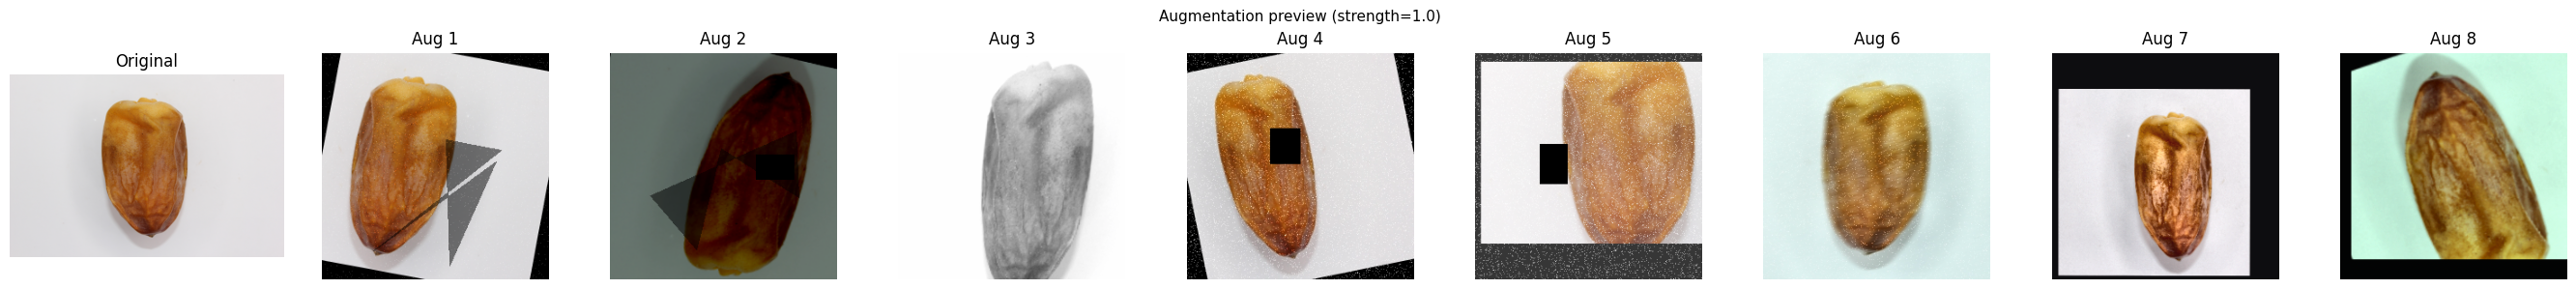

In [9]:
def preview_augmentations(image_path: str, n_versions: int = 8,
                           img_size: int = 260, strength: float = 1.0):
    """
    Show original + n augmented versions.
    Lower AUG_STRENGTH if images look unrecognisable.
    """
    tfm    = get_train_transform(img_size, strength)
    img_np = np.array(PILImage.open(image_path).convert("RGB"))

    fig, axes = plt.subplots(1, n_versions + 1, figsize=((n_versions + 1) * 3, 3))
    axes[0].imshow(img_np); axes[0].set_title("Original"); axes[0].axis("off")

    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    for i in range(1, n_versions + 1):
        aug = tfm(image=img_np)["image"]
        img_show = aug.permute(1, 2, 0).numpy() * std + mean
        axes[i].imshow(img_show.clip(0, 1))
        axes[i].set_title(f"Aug {i}")
        axes[i].axis("off")

    plt.suptitle(f"Augmentation preview (strength={strength})", fontsize=11)
    plt.tight_layout()
    plt.savefig(str(LOGS_DIR / "aug_preview.png"), dpi=100)
    plt.show()


# Run preview on a random training image
try:
    first_class = next(TRAIN_DIR.iterdir())
    first_img   = next(first_class.iterdir())
    preview_augmentations(str(first_img), n_versions=8,
                          img_size=IMG_SIZE, strength=AUG_STRENGTH)
except StopIteration:
    print("⚠️  Run Cell 5 first to create the train split.")


## 🗄️ Cell 8 — Dataset & DataLoaders

/tmp/ipykernel_55/126874861.py:23: UserWarning: Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform RandomShadow
  A.RandomShadow(shadow_roi=(0, 0.3, 1, 1), num_shadows_lower=1, num_shadows_upper=2,
/tmp/ipykernel_55/126874861.py:41: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 60.0)),
/tmp/ipykernel_55/126874861.py:45: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=55, quality_upper=95, p=0.3 * s),
/tmp/ipykernel_55/126874861.py:48: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(
/tmp/ipykernel_55/2964028115.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="r

✅ 17 classes: ['ajwa', 'allig', 'amber', 'aseel', 'deglet_nour', 'galaxy', 'kalmi', 'khorma', 'medjool', 'meneifi', 'muzafati', 'nabtat_ali', 'rutab', 'shaishe', 'sokari', 'sugaey', 'zahidi']
   Train: 3443 images
   Val:   738 images
   Test:  744 images


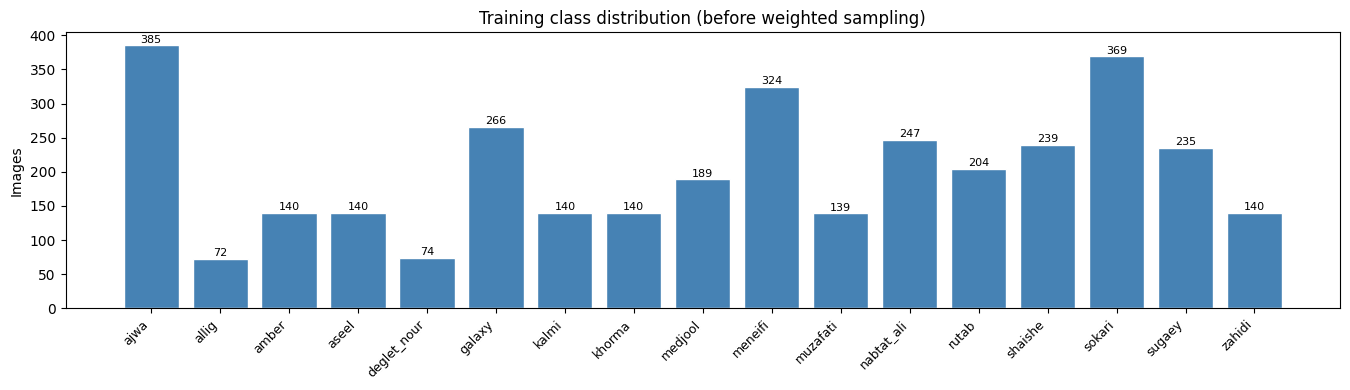


📦 Batches per epoch: 107


In [10]:
class AlbumentationsDataset(torch.utils.data.Dataset):
    """Wraps ImageFolder to accept an Albumentations pipeline."""
    def __init__(self, root, transform: A.Compose):
        self._base        = ImageFolder(str(root))
        self.transform    = transform
        self.classes      = self._base.classes
        self.class_to_idx = self._base.class_to_idx
        self.samples      = self._base.samples

    def __len__(self):
        return len(self._base)

    def __getitem__(self, idx):
        img_pil, label = self._base[idx]
        img_np         = np.array(img_pil)
        augmented      = self.transform(image=img_np)
        return augmented["image"], label


# ── Build datasets ─────────────────────────────────────────────────────────
train_dataset = AlbumentationsDataset(TRAIN_DIR, get_train_transform(IMG_SIZE, AUG_STRENGTH))
val_dataset   = AlbumentationsDataset(VAL_DIR,   get_val_transform(IMG_SIZE))
test_dataset  = AlbumentationsDataset(TEST_DIR,  get_val_transform(IMG_SIZE))

NUM_CLASSES = len(train_dataset.classes)
CLASS_NAMES = train_dataset.classes

print(f"✅ {NUM_CLASSES} classes: {CLASS_NAMES}")
print(f"   Train: {len(train_dataset)} images")
print(f"   Val:   {len(val_dataset)} images")
print(f"   Test:  {len(test_dataset)} images")

# ── Class distribution chart ───────────────────────────────────────────────
targets = [s[1] for s in train_dataset.samples]
counts  = Counter(targets)

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES * 0.8), 4))
bars = ax.bar(CLASS_NAMES, [counts[i] for i in range(NUM_CLASSES)],
              color="steelblue", edgecolor="white")
ax.set_title("Training class distribution (before weighted sampling)")
ax.set_ylabel("Images")
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=9)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            str(int(b.get_height())), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(str(LOGS_DIR / "class_distribution.png"), dpi=120)
plt.show()

# ── Weighted sampler — fixes class imbalance ───────────────────────────────
sample_weights = [1.0 / counts[t] for t in targets]
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True,
)

pin = (DEVICE.type == "cuda")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS,
                          pin_memory=pin, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)

print(f"\n📦 Batches per epoch: {len(train_loader)}")


## 🧠 Cell 9 — Model: EfficientNet-B2

In [11]:
def build_model(num_classes: int, freeze_backbone: bool = True,
               dropout: float = 0.3) -> nn.Module:
    """
    EfficientNet-B2 with a regularised two-layer classifier head.
    Head: Dropout → Linear(1408→512) → BN → SiLU → Dropout → Linear(512→N)
    """
    weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1
    model   = models.efficientnet_b2(weights=weights)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features  # 1408
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.SiLU(),
        nn.Dropout(p=dropout * 0.67),
        nn.Linear(512, num_classes),
    )
    return model


def unfreeze_backbone(model: nn.Module) -> None:
    for param in model.parameters():
        param.requires_grad = True
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"🔓 Backbone unfrozen — {n:,} trainable parameters")


model = build_model(NUM_CLASSES, freeze_backbone=True, dropout=DROPOUT).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\n🔢 Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
print(f"   (backbone frozen for Stage 1)")


Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 160MB/s] 



🔢 Trainable: 731,153 / 8,432,147 (8.7%)
   (backbone frozen for Stage 1)


## 🎲 Cell 10 — MixUp Helper

In [12]:
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0.0:
        return x, y, y, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def mixup_loss(criterion, preds, y_a, y_b, lam):
    return lam * criterion(preds, y_a) + (1 - lam) * criterion(preds, y_b)


print("✅ MixUp helpers defined (set MIXUP_ALPHA=0.0 to disable)")


✅ MixUp helpers defined (set MIXUP_ALPHA=0.0 to disable)


## 🔁 Cell 11 — Training & Validation Loop Functions

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler,
                    device, mixup_alpha=0.2, scaler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc="  train", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        images, y_a, y_b, lam = mixup_data(images, labels, alpha=mixup_alpha)
        optimizer.zero_grad()

        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss   = mixup_loss(criterion, logits, y_a, y_b, lam)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss   = mixup_loss(criterion, logits, y_a, y_b, lam)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        scheduler.step()  # OneCycleLR steps per batch
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader), 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="  eval ", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total


print("✅ train_one_epoch / evaluate defined")


✅ train_one_epoch / evaluate defined


## 🚀 Cell 12 — Stage 1: Train Classifier Head Only

In [14]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING).to(DEVICE)
scaler = torch.amp.GradScaler("cuda") if DEVICE.type == "cuda" else None

optimizer_s1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE1_LR, weight_decay=WEIGHT_DECAY,
)
scheduler_s1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_s1, max_lr=STAGE1_LR,
    steps_per_epoch=len(train_loader), epochs=STAGE1_EPOCHS,
)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
BEST_VAL_ACC  = 0.0
BEST_CKPT     = MODELS_DIR / f"{MODEL_NAME}_best.pth"
patience_left = EARLY_STOP_PATIENCE
global_epoch  = 0

print(f"{'='*65}")
print(f"  STAGE 1 — {STAGE1_EPOCHS} epochs | lr={STAGE1_LR} | backbone frozen")
print(f"  Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} params")
print(f"{'='*65}\n")

for _ in range(STAGE1_EPOCHS):
    global_epoch += 1
    t0 = time.time()

    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, criterion, optimizer_s1, scheduler_s1,
        DEVICE, mixup_alpha=0.0, scaler=scaler,   # no MixUp yet — head is raw
    )
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["lr"].append(optimizer_s1.param_groups[0]["lr"])

    flag = ""
    if vl_acc > BEST_VAL_ACC:
        BEST_VAL_ACC  = vl_acc
        torch.save({"epoch": global_epoch, "model_state": model.state_dict(),
                    "val_acc": vl_acc, "class_names": CLASS_NAMES, "img_size": IMG_SIZE},
                   BEST_CKPT)
        flag          = "  ★ best saved"
        patience_left = EARLY_STOP_PATIENCE
    else:
        patience_left -= 1

    print(f"  Ep {global_epoch:2d}/{STAGE1_EPOCHS}  "
          f"TrLoss={tr_loss:.4f}  TrAcc={tr_acc:5.1f}%  "
          f"VlLoss={vl_loss:.4f}  VlAcc={vl_acc:5.1f}%  "
          f"[{time.time()-t0:.0f}s]{flag}")

    if patience_left == 0:
        print("  ⏹  Early stopping triggered")
        break

print(f"\n✅ Stage 1 done. Best val acc: {BEST_VAL_ACC:.2f}%")


  STAGE 1 — 5 epochs | lr=0.001 | backbone frozen
  Trainable: 731,153 params



  train:   0%|          | 0/107 [00:00<?, ?it/s]

/tmp/ipykernel_55/36814867.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  eval :   0%|          | 0/24 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7de767ba2520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7de767ba2520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

  Ep  4/5  TrLoss=1.4028  TrAcc= 69.4%  VlLoss=0.8899  VlAcc= 91.5%  [307s]


  train:   0%|          | 0/107 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7de767ba2520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7de767ba2520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  eval :   0%|          | 0/24 [00:00<?, ?it/s]

  Ep  5/5  TrLoss=1.3850  TrAcc= 68.9%  VlLoss=0.8822  VlAcc= 92.3%  [329s]

✅ Stage 1 done. Best val acc: 92.41%


## 🔓 Cell 13 — Stage 2: Unfreeze & Fine-Tune End-to-End

In [15]:
unfreeze_backbone(model)
patience_left = EARLY_STOP_PATIENCE

optimizer_s2 = torch.optim.AdamW(
    model.parameters(), lr=STAGE2_LR, weight_decay=WEIGHT_DECAY,
)
scheduler_s2 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_s2, max_lr=STAGE2_LR,
    steps_per_epoch=len(train_loader), epochs=STAGE2_EPOCHS,
)

STAGE1_END = global_epoch  # saved for curve plot

print(f"{'='*65}")
print(f"  STAGE 2 — {STAGE2_EPOCHS} epochs | max_lr={STAGE2_LR} | full model")
print(f"  MixUp alpha={MIXUP_ALPHA}")
print(f"{'='*65}\n")

for _ in range(STAGE2_EPOCHS):
    global_epoch += 1
    t0 = time.time()

    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, criterion, optimizer_s2, scheduler_s2,
        DEVICE, mixup_alpha=MIXUP_ALPHA, scaler=scaler,
    )
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["lr"].append(optimizer_s2.param_groups[0]["lr"])

    flag = ""
    if vl_acc > BEST_VAL_ACC:
        BEST_VAL_ACC  = vl_acc
        torch.save({"epoch": global_epoch, "model_state": model.state_dict(),
                    "val_acc": vl_acc, "class_names": CLASS_NAMES, "img_size": IMG_SIZE},
                   BEST_CKPT)
        flag          = "  ★ best saved"
        patience_left = EARLY_STOP_PATIENCE
    else:
        patience_left -= 1

    total_ep = STAGE1_EPOCHS + STAGE2_EPOCHS
    print(f"  Ep {global_epoch:2d}/{total_ep}  "
          f"TrLoss={tr_loss:.4f}  TrAcc={tr_acc:5.1f}%  "
          f"VlLoss={vl_loss:.4f}  VlAcc={vl_acc:5.1f}%  "
          f"[{time.time()-t0:.0f}s]{flag}")

    if patience_left == 0:
        print("  ⏹  Early stopping triggered")
        break

print(f"\n✅ Training complete!  Best val acc: {BEST_VAL_ACC:.2f}%")
print(f"   Best checkpoint: {BEST_CKPT}")


🔓 Backbone unfrozen — 8,432,147 trainable parameters
  STAGE 2 — 10 epochs | max_lr=0.0005 | full model
  MixUp alpha=0.2



  train:   0%|          | 0/107 [00:00<?, ?it/s]

/tmp/ipykernel_55/36814867.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_55/36814867.py:30: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()  # OneCycleLR steps per batch


  eval :   0%|          | 0/24 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7de767ba2520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7de767ba2520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

  Ep 14/15  TrLoss=1.0569  TrAcc= 51.3%  VlLoss=0.6079  VlAcc= 99.7%  [334s]


  train:   0%|          | 0/107 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7de767ba2520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
    Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7de767ba2520> 
Traceback (most recent call last):
 ^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    if w.is_alive():^
^^ ^ ^ ^ ^   
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^  ^ ^^  ^^^  ^  
   File "/usr/

  eval :   0%|          | 0/24 [00:00<?, ?it/s]

  Ep 15/15  TrLoss=1.0102  TrAcc= 47.4%  VlLoss=0.6073  VlAcc= 99.6%  [365s]

✅ Training complete!  Best val acc: 99.73%
   Best checkpoint: /kaggle/working/models/nakhlah_robust_v1_best.pth


## 📈 Cell 14 — Training Curves

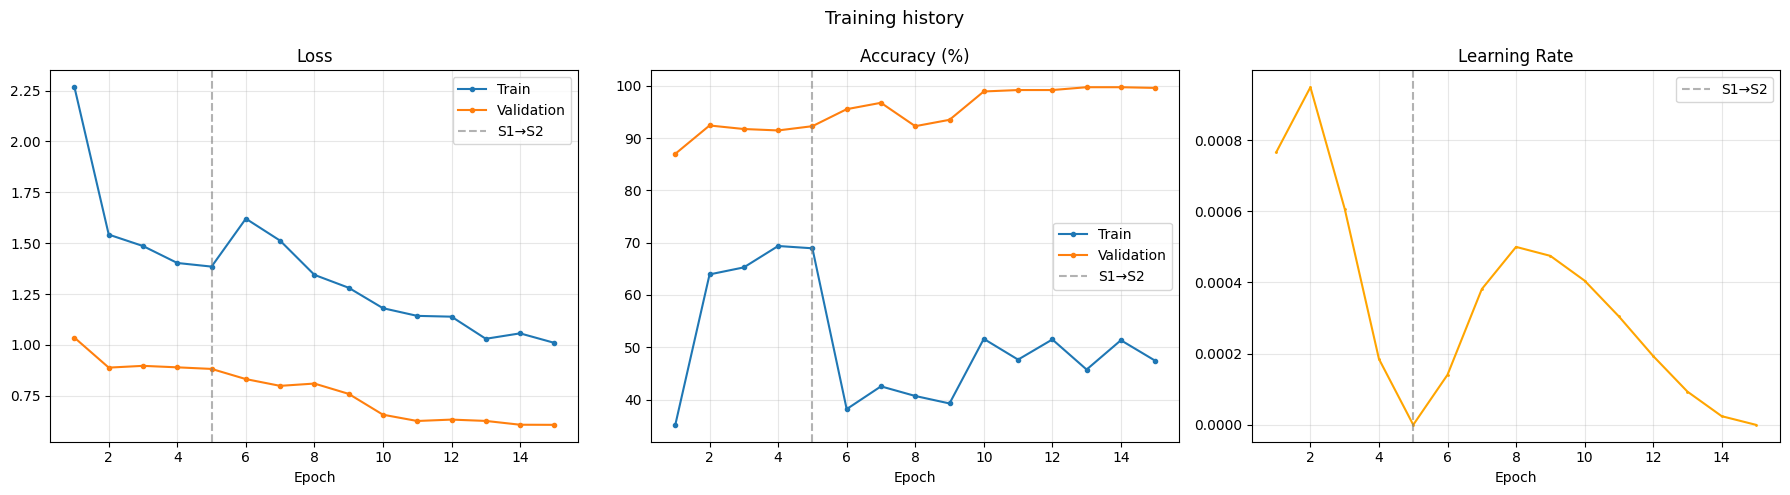

In [16]:
n_ep = len(history["train_loss"])
xs   = range(1, n_ep + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training history", fontsize=13)

axes[0].plot(xs, history["train_loss"], label="Train",      marker="o", ms=3)
axes[0].plot(xs, history["val_loss"],   label="Validation", marker="o", ms=3)
axes[0].axvline(STAGE1_END, color="gray", ls="--", alpha=0.6, label="S1→S2")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(xs, history["train_acc"], label="Train",      marker="o", ms=3)
axes[1].plot(xs, history["val_acc"],   label="Validation", marker="o", ms=3)
axes[1].axvline(STAGE1_END, color="gray", ls="--", alpha=0.6, label="S1→S2")
axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(xs, history["lr"], color="orange", marker=".", ms=2)
axes[2].axvline(STAGE1_END, color="gray", ls="--", alpha=0.6, label="S1→S2")
axes[2].set_title("Learning Rate"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(LOGS_DIR / "training_curves.png"), dpi=120)
plt.show()


## 🧪 Cell 15 — Test Set Evaluation (Standard)

In [17]:
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print(f"📂 Loaded best checkpoint — epoch {ckpt['epoch']}, val acc {ckpt['val_acc']:.2f}%")

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE, non_blocking=True)
        preds  = model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = 100.0 * (all_preds == all_labels).mean()
print(f"\n🎯 Test Accuracy (standard): {test_acc:.2f}%")
print("\n" + classification_report(all_labels, all_preds,
                                   target_names=CLASS_NAMES, digits=3))


📂 Loaded best checkpoint — epoch 13, val acc 99.73%


Testing:   0%|          | 0/24 [00:00<?, ?it/s]


🎯 Test Accuracy (standard): 99.06%

              precision    recall  f1-score   support

        ajwa      1.000     0.952     0.975        83
       allig      1.000     1.000     1.000        16
       amber      1.000     1.000     1.000        30
       aseel      1.000     1.000     1.000        30
 deglet_nour      1.000     1.000     1.000        16
      galaxy      1.000     0.965     0.982        57
       kalmi      0.882     1.000     0.938        30
      khorma      1.000     1.000     1.000        30
     medjool      1.000     1.000     1.000        41
     meneifi      1.000     1.000     1.000        70
    muzafati      1.000     1.000     1.000        30
  nabtat_ali      1.000     1.000     1.000        54
       rutab      1.000     1.000     1.000        44
     shaishe      1.000     1.000     1.000        52
      sokari      0.976     1.000     0.988        80
      sugaey      0.980     0.980     0.980        51
      zahidi      1.000     1.000     1.000 

## 🔮 Cell 16 — Test-Time Augmentation (TTA, 5 views)

In [20]:
def tta_predict(model, loader, device, img_size=260, n_augments=5):
    """
    Averages predictions over 5 views per image:
    view 0 = deterministic centre crop, views 1-4 = random crops/flips.
    Typically gives +2–5% accuracy vs single-crop on real-world images.
    """
    tta_tfm = A.Compose([
        A.RandomResizedCrop(size=(img_size, img_size), scale=(0.85, 1.0)),
        A.HorizontalFlip(p=0.5),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])
    val_tfm = get_val_transform(img_size)

    mean_np = np.array(IMAGENET_MEAN)
    std_np  = np.array(IMAGENET_STD)

    model.eval()
    all_preds, all_labels = [], []

    for images_batch, labels in tqdm(loader, desc="TTA"):
        bsz   = images_batch.size(0)
        n_cls = model.classifier[-1].out_features
        accum = torch.zeros(bsz, n_cls).to(device)

        for aug_idx in range(n_augments):
            aug_batch = []
            for img_t in images_batch:
                img_np = img_t.permute(1, 2, 0).numpy()
                img_np = (img_np * std_np + mean_np)
                img_np = (img_np * 255).clip(0, 255).astype(np.uint8)
                tfm = val_tfm if aug_idx == 0 else tta_tfm
                aug_batch.append(tfm(image=img_np)["image"])

            aug_tensor = torch.stack(aug_batch).to(device)
            with torch.no_grad():
                accum += F.softmax(model(aug_tensor), dim=1)

        all_preds.extend(accum.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)


tta_preds, tta_labels = tta_predict(model, test_loader, DEVICE,
                                     img_size=IMG_SIZE, n_augments=5)

tta_acc = 100.0 * (tta_preds == tta_labels).mean()
print(f"\n🎯 Test Accuracy with TTA: {tta_acc:.2f}%")
print(f"   Improvement over standard: +{tta_acc - test_acc:.2f}%")
print("\n" + classification_report(tta_labels, tta_preds,
                                   target_names=CLASS_NAMES, digits=3))


TTA:   0%|          | 0/24 [00:00<?, ?it/s]


🎯 Test Accuracy with TTA: 99.33%
   Improvement over standard: +0.27%

              precision    recall  f1-score   support

        ajwa      0.988     0.988     0.988        83
       allig      1.000     1.000     1.000        16
       amber      1.000     1.000     1.000        30
       aseel      1.000     1.000     1.000        30
 deglet_nour      1.000     1.000     1.000        16
      galaxy      1.000     0.982     0.991        57
       kalmi      0.967     0.967     0.967        30
      khorma      1.000     1.000     1.000        30
     medjool      0.976     1.000     0.988        41
     meneifi      1.000     0.986     0.993        70
    muzafati      1.000     1.000     1.000        30
  nabtat_ali      1.000     1.000     1.000        54
       rutab      1.000     1.000     1.000        44
     shaishe      1.000     1.000     1.000        52
      sokari      0.976     1.000     0.988        80
      sugaey      1.000     0.980     0.990        51
      zah

## 🗺️ Cell 17 — Confusion Matrix

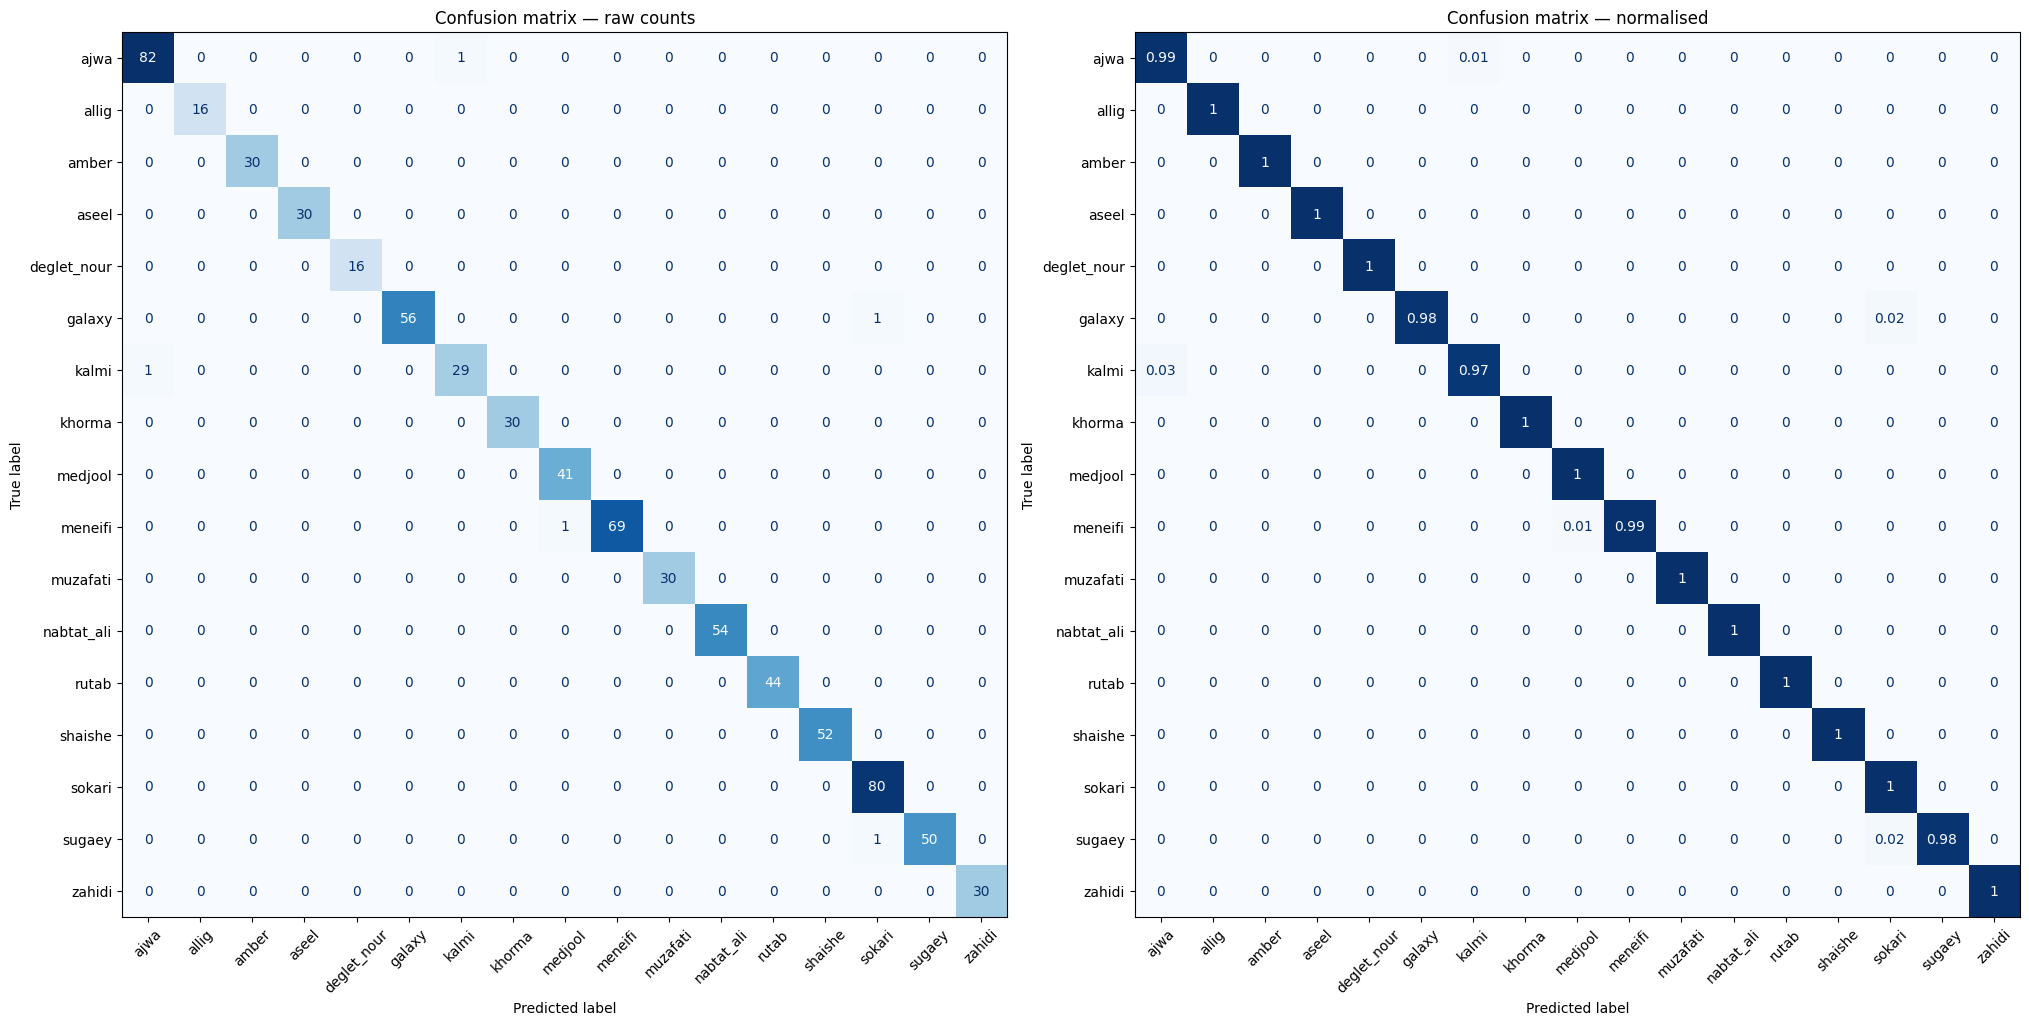

In [21]:
cm      = confusion_matrix(tta_labels, tta_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(max(14, NUM_CLASSES * 1.2),
                                        max(6,  NUM_CLASSES * 0.9)))

ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], xticks_rotation=45, colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion matrix — raw counts")

ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASS_NAMES).plot(
    ax=axes[1], xticks_rotation=45, colorbar=False, cmap="Blues"
)
axes[1].set_title("Confusion matrix — normalised")

plt.tight_layout()
plt.savefig(str(LOGS_DIR / "confusion_matrix.png"), dpi=120)
plt.show()


## 💾 Cell 18 — Save Final Model + Metadata

In [22]:
final_ckpt = MODELS_DIR / f"{MODEL_NAME}_final.pth"
torch.save({
    "epoch":       global_epoch,
    "model_state": model.state_dict(),
    "val_acc":     history["val_acc"][-1],
    "class_names": CLASS_NAMES,
    "img_size":    IMG_SIZE,
}, final_ckpt)

metadata = {
    "model":           "efficientnet_b2",
    "num_classes":     NUM_CLASSES,
    "class_names":     CLASS_NAMES,
    "best_val_acc":    round(BEST_VAL_ACC, 4),
    "test_acc":        round(test_acc, 4),
    "test_acc_tta":    round(tta_acc, 4),
    "epochs_ran":      global_epoch,
    "stage1_epochs":   STAGE1_END,
    "img_size":        IMG_SIZE,
    "img_mean":        list(IMAGENET_MEAN),
    "img_std":         list(IMAGENET_STD),
    "mixup_alpha":     MIXUP_ALPHA,
    "label_smoothing": LABEL_SMOOTHING,
    "aug_strength":    AUG_STRENGTH,
}
meta_path = MODELS_DIR / f"{MODEL_NAME}_metadata.json"
meta_path.write_text(json.dumps(metadata, indent=2))

print("✅ Saved:")
print(f"   Best checkpoint  → {BEST_CKPT}")
print(f"   Final checkpoint → {final_ckpt}")
print(f"   Metadata         → {meta_path}")
print(f"\n🏆 Summary:")
print(f"   Best Val Acc  : {BEST_VAL_ACC:.2f}%")
print(f"   Test Acc      : {test_acc:.2f}%")
print(f"   Test Acc (TTA): {tta_acc:.2f}%")


✅ Saved:
   Best checkpoint  → /kaggle/working/models/nakhlah_robust_v1_best.pth
   Final checkpoint → /kaggle/working/models/nakhlah_robust_v1_final.pth
   Metadata         → /kaggle/working/models/nakhlah_robust_v1_metadata.json

🏆 Summary:
   Best Val Acc  : 99.73%
   Test Acc      : 99.06%
   Test Acc (TTA): 99.33%


## 🔍 Cell 19 — Single Image Inference

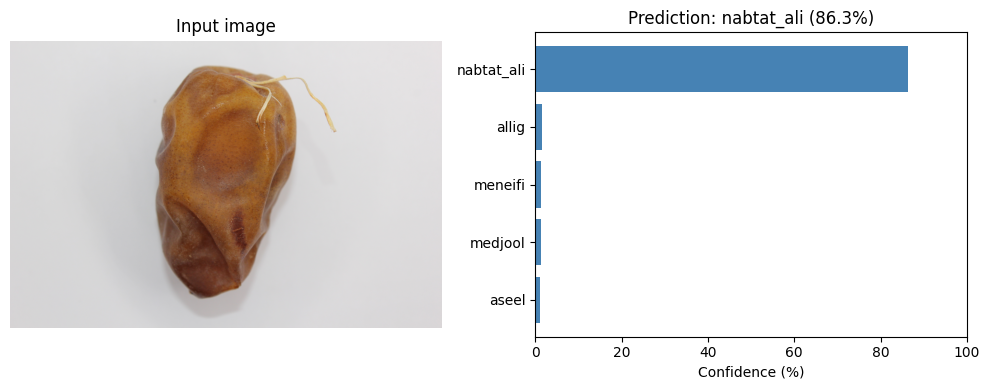

True class  : nabtat_ali
Predicted   : nabtat_ali (86.3%)
Top-5 probs : {'nabtat_ali': 0.8631, 'allig': 0.0142, 'meneifi': 0.0134, 'medjool': 0.0129, 'aseel': 0.0112}


In [24]:
def predict_image(image_path: str, ckpt_path: str = str(BEST_CKPT),
                  use_tta: bool = True) -> dict:
    """
    Classify a single real-world image.
    use_tta=True averages 5 views for better real-world accuracy.
    """
    ckpt      = torch.load(ckpt_path, map_location=DEVICE)
    cls_names = ckpt.get("class_names", CLASS_NAMES)
    n_cls     = len(cls_names)
    sz        = ckpt.get("img_size", IMG_SIZE)

    inf_model = build_model(n_cls, freeze_backbone=False).to(DEVICE)
    inf_model.load_state_dict(ckpt["model_state"])
    inf_model.eval()

    img_np  = np.array(PILImage.open(image_path).convert("RGB"))
    val_tfm = get_val_transform(sz)
    tta_tfm = A.Compose([
        A.RandomResizedCrop(size=(sz, sz), scale=(0.85, 1.0)),
        A.HorizontalFlip(p=0.5),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

    if use_tta:
        views = [val_tfm(image=img_np)["image"]]
        for _ in range(4):
            views.append(tta_tfm(image=img_np)["image"])
        batch = torch.stack(views).to(DEVICE)
        with torch.no_grad():
            probs = F.softmax(inf_model(batch), dim=1).mean(0)
    else:
        tensor = val_tfm(image=img_np)["image"].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs = F.softmax(inf_model(tensor), dim=1).squeeze()

    top5_v, top5_i = probs.topk(min(5, n_cls))
    top5 = {cls_names[i]: round(v.item(), 4) for i, v in zip(top5_i, top5_v)}

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(PILImage.open(image_path).convert("RGB"))
    axes[0].set_title("Input image"); axes[0].axis("off")
    axes[1].barh(list(top5.keys())[::-1], [v * 100 for v in list(top5.values())[::-1]],
                 color="steelblue")
    axes[1].set_xlabel("Confidence (%)")
    axes[1].set_title(f"Prediction: {cls_names[top5_i[0]]} ({top5_v[0]*100:.1f}%)")
    axes[1].set_xlim(0, 100)
    plt.tight_layout()
    plt.show()

    return {"class": cls_names[top5_i[0].item()],
            "confidence": round(top5_v[0].item() * 100, 2),
            "top5_probs": top5}


# ── Sanity check on a random test image ──────────────────────────────────
try:
    sample_class = next(TEST_DIR.iterdir())
    sample_img   = next(sample_class.iterdir())
    result = predict_image(str(sample_img), use_tta=True)
    print(f"True class  : {sample_class.name}")
    print(f"Predicted   : {result['class']} ({result['confidence']:.1f}%)")
    print(f"Top-5 probs : {result['top5_probs']}")
except Exception as e:
    print(f"⚠️  Run cells 4-5 first to prepare data. Error: {e}")
    print("    Usage: result = predict_image('path/to/your/image.jpg')")
